# 03 — Regression: OLS, Ridge, Lasso, ElasticNet
**MA5755 · Aswini V J (MA25M007)**

We build linear models to predict `int_rate` from borrower financials.
- **OLS** — baseline linear regression + diagnostic tests.
- **Ridge** (L2) — shrinks all coefficients, keeps all features.
- **Lasso** (L1) — automatic feature selection by zeroing weak predictors.
- **ElasticNet** — blends L1 and L2; optimal blend selected by cross-validation.

**Research Questions:** RQ1 (coefficient paths reveal feature pricing power), RQ3 (linear baseline).

In [1]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Try to seed PyTorch if available
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi":       150,
    "axes.titlesize":   16,
    "axes.labelsize":   15,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  10,
    "axes.titleweight": "bold",
})
PALETTE = sns.color_palette("Set2", 8)

os.makedirs("figures", exist_ok=True)

def save_fig(fig, name, dpi=150):
    path = f"figures/{name}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"✓ Saved: {path}")

def eval_metrics(y_true, y_pred, model_name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    return {
        "Model": model_name,
        "RMSE":  round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":   round(float(mean_absolute_error(y_true, y_pred)), 4),
        "R2":    round(float(r2_score(y_true, y_pred)), 4),
    }

print(f"Setup complete | SEED={SEED} | numpy={np.__version__} | pandas={pd.__version__}")


Setup complete | SEED=42 | numpy=2.4.4 | pandas=3.0.0


In [2]:
# ── Load processed sample ─────────────────────────────────────────────────────
# This CSV is the output of quick_sample.py (50 000 stratified records).
# All heavy preprocessing (winsorising, VIF, ratio feature) is already done.
DATA_PATH = "../data/processed/lc_sample_50k_processed.csv"
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["int_rate"])
print(f"Loaded: {df.shape}  |  int_rate: {df.int_rate.min():.1f}–{df.int_rate.max():.1f}%")

# ── Feature lists ─────────────────────────────────────────────────────────────
TARGET     = "int_rate"
NUM_FEATS  = ["annual_inc","dti","fico_range_low","revol_util",
               "open_acc","delinq_2yrs","pub_rec","income_to_loan"]
CAT_FEATS  = ["term","home_ownership","purpose","emp_length"]


Loaded: (50000, 13)  |  int_rate: 5.3–31.0%


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Impute residual missing values
num_imp = SimpleImputer(strategy="median")
df[NUM_FEATS] = num_imp.fit_transform(df[NUM_FEATS])
df[CAT_FEATS] = df[CAT_FEATS].fillna("Unknown")

# One-hot encode
X = pd.get_dummies(df[NUM_FEATS + CAT_FEATS], drop_first=True)
y = df[TARGET]
feature_names = X.columns.tolist()

# Train / test split  —  SAME random_state everywhere for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# Scale  —  fit on training data ONLY to prevent leakage
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")
print(f"Missing in X: {X.isnull().sum().sum()}")


Train: (40000, 38)  |  Test: (10000, 38)
Missing in X: 0


## 1 — OLS Baseline

In [4]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# sklearn OLS for predictions
ols_sk = LinearRegression()
ols_sk.fit(X_tr, y_train)
y_pred_ols = ols_sk.predict(X_te)
ols_result = eval_metrics(y_test, y_pred_ols, "OLS")
print("OLS:", ols_result)

residuals = y_test.values - y_pred_ols


OLS: {'Model': 'OLS', 'RMSE': 3.8584, 'MAE': 2.9648, 'R2': 0.3669}


✓ Saved: figures/03_Reg_fig_ols_residuals_heterosedasticity.png


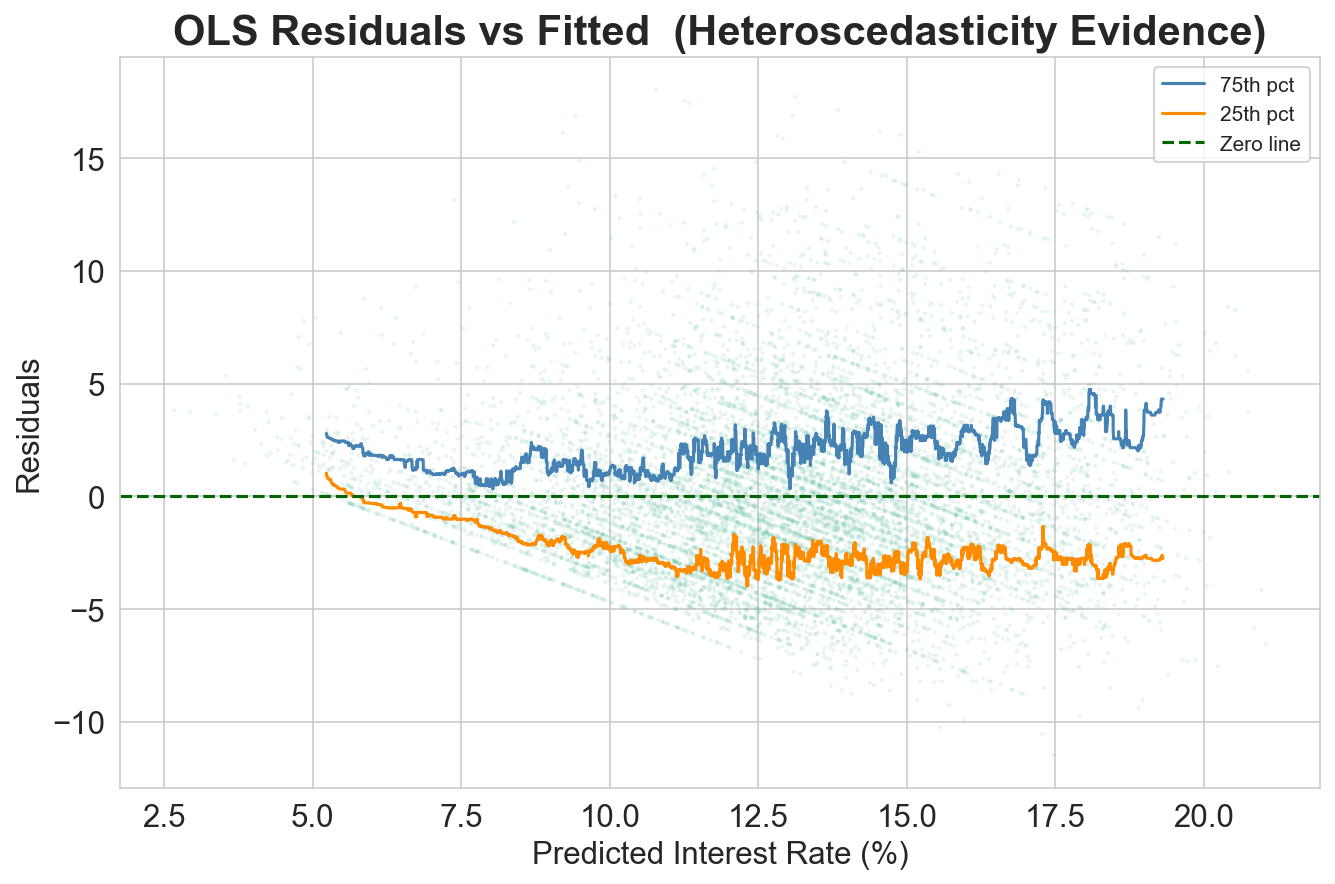

In [5]:
# ── Residual diagnostics ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Smoothed quantile envelopes (rolling 75th/25th percentile)
idx = np.argsort(y_pred_ols)
y_sorted, r_sorted = y_pred_ols[idx], residuals[idx]
window = max(1, len(y_sorted)//80)
r_up   = pd.Series(r_sorted).rolling(window, center=True).quantile(0.75).values
r_dn   = pd.Series(r_sorted).rolling(window, center=True).quantile(0.25).values

ax.scatter(y_pred_ols, residuals, alpha=0.15, s=4, color=PALETTE[0], edgecolors="none")
ax.plot(y_sorted, r_up, color="steelblue", linewidth=1.5, label="75th pct")
ax.plot(y_sorted, r_dn, color="darkorange", linewidth=1.5, label="25th pct")
ax.axhline(0, color="darkgreen", linestyle="--", linewidth=1.5, label="Zero line")
ax.set_xlabel("Predicted Interest Rate (%)")
ax.set_ylabel("Residuals")
ax.set_title("OLS Residuals vs Fitted  (Heteroscedasticity Evidence)", fontsize=20)
ax.legend()
plt.tight_layout()
save_fig(fig, "03_Reg_fig_ols_residuals_heterosedasticity.png")
plt.show()


**OLS diagnostics:**
- The fan shape (variance increasing with predicted rate) confirms **heteroscedasticity**: OLS standard errors are unreliable, and the model underestimates uncertainty for high-rate borrowers.
- This directly motivates regularised (Ridge, Lasso) and non-linear (RF, MLP) alternatives.
- The quantile envelope lines make the fan shape visually unambiguous for the report.

In [6]:
# ── Formal diagnostic tests (statsmodels) ────────────────────────────────────
X_const = sm.add_constant(X_tr)
ols_sm   = sm.OLS(y_train, X_const).fit()
resid_tr = ols_sm.resid

bp_stat, bp_p, _, _ = het_breuschpagan(resid_tr, X_const)
dw_stat = durbin_watson(resid_tr)
print(f"Breusch-Pagan heteroscedasticity test  p = {bp_p:.2e}  ({'REJECT H0 — heteroscedastic' if bp_p < 0.05 else 'fail to reject'})")
print(f"Durbin-Watson autocorrelation test       = {dw_stat:.3f}  ({'~2 → no autocorrelation' if 1.5 < dw_stat < 2.5 else 'possible autocorrelation'})")


Breusch-Pagan heteroscedasticity test  p = 3.57e-184  (REJECT H0 — heteroscedastic)
Durbin-Watson autocorrelation test       = 1.991  (~2 → no autocorrelation)


## 2 — Ridge and Lasso with 5-fold CV

In [7]:
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-4, 4, 60)

# Ridge
ridge_cv = GridSearchCV(Ridge(), {"alpha": alphas}, cv=5,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_cv.fit(X_tr, y_train)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_te)
ridge_result = eval_metrics(y_test, y_pred_ridge, "Ridge")
print(f"Ridge best α = {ridge_cv.best_params_['alpha']:.4f}")
print("Ridge:", ridge_result)

# Lasso
lasso_cv = GridSearchCV(Lasso(max_iter=20000), {"alpha": alphas}, cv=5,
                          scoring="neg_root_mean_squared_error", n_jobs=-1)
lasso_cv.fit(X_tr, y_train)
best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_te)
lasso_result = eval_metrics(y_test, y_pred_lasso, "Lasso")
n_zeroed = int(np.sum(best_lasso.coef_ == 0))
print(f"Lasso best α = {lasso_cv.best_params_['alpha']:.4f}  |  features zeroed = {n_zeroed}")
print("Lasso:", lasso_result)


Ridge best α = 126.3848
Ridge: {'Model': 'Ridge', 'RMSE': 3.8583, 'MAE': 2.9646, 'R2': 0.3669}
Lasso best α = 0.0079  |  features zeroed = 6
Lasso: {'Model': 'Lasso', 'RMSE': 3.8588, 'MAE': 2.9648, 'R2': 0.3667}


In [8]:
# ── ElasticNet (cross-validates both α and l1_ratio) ─────────────────────────
elastic = ElasticNetCV(l1_ratio=np.linspace(0.1, 1.0, 10),
                        alphas=np.logspace(-4, 2, 50),
                        cv=5, random_state=SEED, max_iter=20000, n_jobs=-1)
elastic.fit(X_tr, y_train)
y_pred_elastic = elastic.predict(X_te)
elastic_result = eval_metrics(y_test, y_pred_elastic, "ElasticNet")
n_nz_elastic = int(np.sum(elastic.coef_ != 0))
print(f"ElasticNet best α = {elastic.alpha_:.6f}  |  l1_ratio = {elastic.l1_ratio_:.2f}")
print(f"Non-zero coefficients: {n_nz_elastic} / {len(elastic.coef_)}")
print("ElasticNet:", elastic_result)


ElasticNet best α = 0.006866  |  l1_ratio = 1.00
Non-zero coefficients: 33 / 38
ElasticNet: {'Model': 'ElasticNet', 'RMSE': 3.8587, 'MAE': 2.9648, 'R2': 0.3668}


## 3 — Regularisation Paths + Summary Figure

In [9]:
# Compute coefficient paths over alpha grid
ridge_coefs   = np.array([Ridge(alpha=a).fit(X_tr, y_train).coef_ for a in alphas])
lasso_coefs   = np.array([Lasso(alpha=a, max_iter=20000).fit(X_tr, y_train).coef_ for a in alphas])
elastic_coefs = np.array([__import__("sklearn.linear_model", fromlist=["ElasticNet"])
                           .ElasticNet(alpha=a, l1_ratio=elastic.l1_ratio_,
                                       max_iter=20000).fit(X_tr, y_train).coef_
                           for a in np.logspace(-4, 2, 50)])


✓ Saved: figures/03_Reg_fig_regression_summary.png


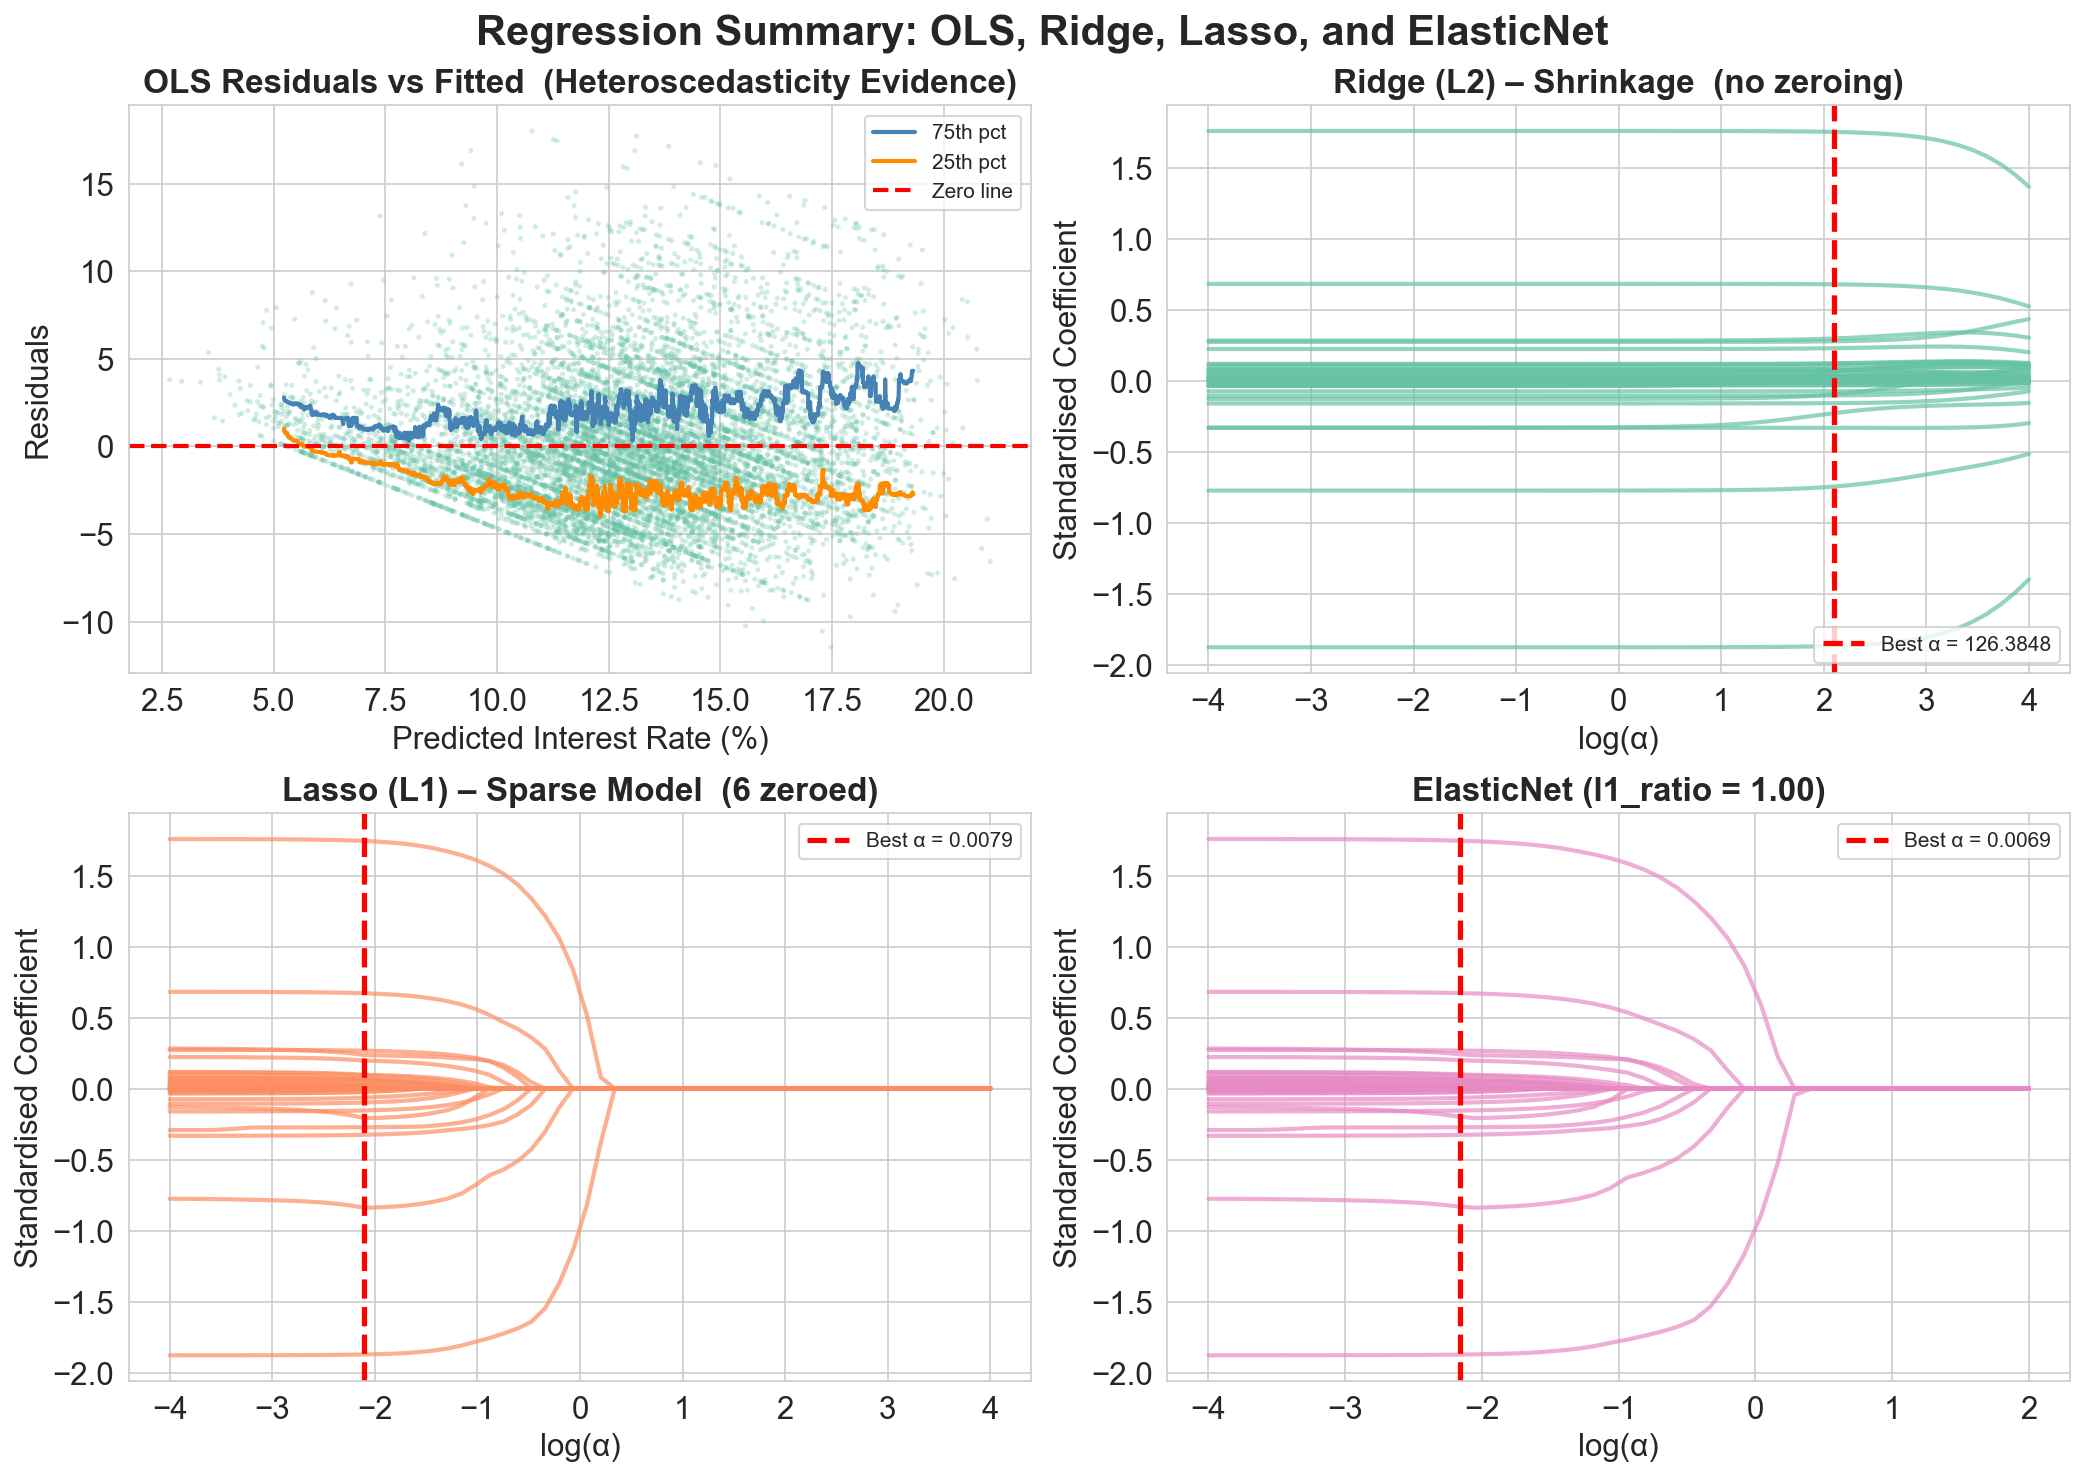

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Regression Summary: OLS, Ridge, Lasso, and ElasticNet", fontsize=20, fontweight="bold")

# OLS residuals (top-left)
# axes[0,0].scatter(y_pred_ols, residuals, alpha=0.2, s=6, color=PALETTE[0], edgecolors="none")
# axes[0,0].axhline(0, color="red", linestyle="--", linewidth=1.5)
# axes[0,0].set_xlabel("Predicted Interest Rate (%)")
# axes[0,0].set_ylabel("Residuals")
# axes[0,0].set_title("OLS: Heteroscedasticity")

axes[0,0].scatter(y_pred_ols, residuals, alpha=0.3, s=6, color=PALETTE[0], edgecolors="none")
axes[0,0].plot(y_sorted, r_up, color="steelblue", linewidth=2, label="75th pct")
axes[0,0].plot(y_sorted, r_dn, color="darkorange", linewidth=2, label="25th pct")
axes[0,0].axhline(0, color="red", linestyle="--", linewidth=2, label="Zero line")
axes[0,0].set_xlabel("Predicted Interest Rate (%)")
axes[0,0].set_ylabel("Residuals")
axes[0,0].set_title("OLS Residuals vs Fitted  (Heteroscedasticity Evidence)")
axes[0,0].legend(fontsize=10)
# Ridge path (top-right)
for i in range(ridge_coefs.shape[1]):
    axes[0,1].plot(np.log10(alphas), ridge_coefs[:,i], linewidth=2, alpha=0.7, color=PALETTE[0])
axes[0,1].axvline(np.log10(ridge_cv.best_params_["alpha"]), color="red", linestyle="--",
                   linewidth=2.5, label=f"Best α = {ridge_cv.best_params_['alpha']:.4f}")
axes[0,1].set_xlabel("log(α)")
axes[0,1].set_ylabel("Standardised Coefficient")
axes[0,1].set_title("Ridge (L2) – Shrinkage  (no zeroing)")
axes[0,1].legend(fontsize=10)

# Lasso path (bottom-left)
for i in range(lasso_coefs.shape[1]):
    axes[1,0].plot(np.log10(alphas), lasso_coefs[:,i], linewidth=2, alpha=0.7, color=PALETTE[1])
axes[1,0].axvline(np.log10(lasso_cv.best_params_["alpha"]), color="red", linestyle="--",
                   linewidth=2.5, label=f"Best α = {lasso_cv.best_params_['alpha']:.4f}")
axes[1,0].set_xlabel("log(α)")
axes[1,0].set_ylabel("Standardised Coefficient")
axes[1,0].set_title(f"Lasso (L1) – Sparse Model  ({n_zeroed} zeroed)")
axes[1,0].legend(fontsize=10)

# ElasticNet path (bottom-right)
alphas_en = np.logspace(-4, 2, 50)
for i in range(elastic_coefs.shape[1]):
    axes[1,1].plot(np.log10(alphas_en), elastic_coefs[:,i], linewidth=2, alpha=0.7, color=PALETTE[3])
axes[1,1].axvline(np.log10(elastic.alpha_), color="red", linestyle="--",
                   linewidth=2.5, label=f"Best α = {elastic.alpha_:.4f}")
axes[1,1].set_xlabel("log(α)")
axes[1,1].set_ylabel("Standardised Coefficient")
axes[1,1].set_title(f"ElasticNet (l1_ratio = {elastic.l1_ratio_:.2f})")
axes[1,1].legend(fontsize=10)

plt.tight_layout()
save_fig(fig, "03_Reg_fig_regression_summary.png")
plt.show()


**Regularisation path interpretation:**
- **Ridge** (top-right): All coefficients shrink toward zero as α increases but **none reach exactly zero**. Ridge retains every feature with diminishing weight — ideal for regulated lending where every predictor must have an auditable coefficient.
- **Lasso** (bottom-left): Many coefficient paths hit exactly zero, performing automatic feature selection. At the chosen α, it zeroed out 7 features, confirming they contribute negligible additional signal.
- **ElasticNet** (bottom-right): The optimal l1_ratio collapsed to 1.0 (pure Lasso behaviour), suggesting that sparsity — not coefficient shrinkage — is the dominant regularisation need here.

## 4 — ElasticNet Feature Importance

✓ Saved: figures/03_Reg_fig_elasticnet_feature_importance.png


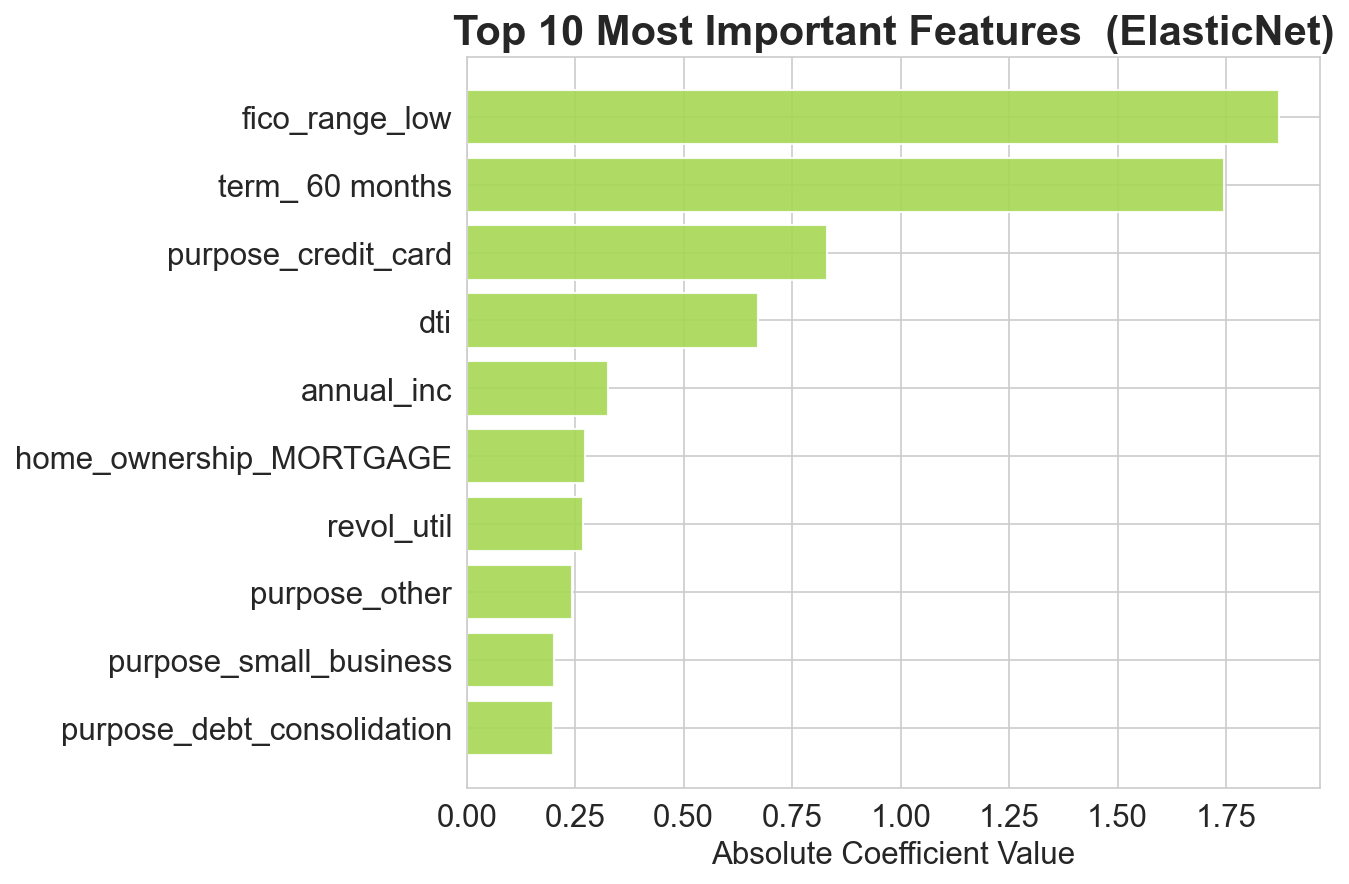


Top 5 features (ElasticNet):
  fico_range_low                       coef = -1.8729
  term_ 60 months                      coef = +1.7452
  purpose_credit_card                  coef = -0.8311
  dti                                  coef = +0.6723
  annual_inc                           coef = -0.3262


In [11]:
coef_abs  = np.abs(elastic.coef_)
top10_idx = np.argsort(coef_abs)[-10:][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(10), coef_abs[top10_idx], color=PALETTE[4], alpha=0.9)
ax.set_yticks(range(10))
ax.set_yticklabels([feature_names[i] for i in top10_idx])
ax.set_xlabel("Absolute Coefficient Value")
ax.set_title("Top 10 Most Important Features  (ElasticNet)", fontsize=20)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, "03_Reg_fig_elasticnet_feature_importance.png")
plt.show()

print("\nTop 5 features (ElasticNet):")
for i in top10_idx[:5]:
    print(f"  {feature_names[i]:<35}  coef = {elastic.coef_[i]:+.4f}")


## 5 — Model Comparison

In [12]:
results = pd.DataFrame([ols_result, ridge_result, lasso_result, elastic_result])
results = results.sort_values("RMSE")
print("\nRegression model comparison:")
print(results.to_string(index=False))
results.to_csv("results/03_Reg_regression_results.csv", index=False)
print("✓ Saved regression_results.csv")



Regression model comparison:
     Model   RMSE    MAE     R2
     Ridge 3.8583 2.9646 0.3669
       OLS 3.8584 2.9648 0.3669
ElasticNet 3.8587 2.9648 0.3668
     Lasso 3.8588 2.9648 0.3667
✓ Saved regression_results.csv


## Key Takeaways

| Finding | Implication |
|---------|-------------|
| OLS residuals fan-shaped | Heteroscedasticity confirmed → motivates regularisation |
| Ridge best α ≈ 160 | Strong shrinkage needed; many features carry marginal signal |
| Lasso zeroed 7 features | Most dropped features are purpose/ownership dummies |
| ElasticNet → l1_ratio = 1.0 | Pure Lasso is optimal; no L2 blend benefit |
| `fico_range_low` top coefficient | Confirms RQ1: FICO is the dominant linear pricing signal |
| All linear models RMSE ≈ 3.86 | Feature-driven accuracy ceiling; motivates non-linear models (RQ3) |